# Detect → Crop → Classify (YOLOv10 + SWIN)

This notebook loads:
- a **YOLO** detector (best.pt) to find pedestrian traffic lights in an input image,
- a **Swin Transformer** classifier (best_swin.pth) to classify the **largest** detected light into `red / yellow / green`.

Update the paths in the **Config** cell, then run the **Pipeline** cell.

In [27]:
# Install dependencies (safe on Colab; no-op locally if already installed)
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print("Running on Colab:", IN_COLAB)

!pip -q install --upgrade ultralytics timm

Running on Colab: False


In [29]:
import os, random, time
from pathlib import Path
import numpy as np
import torch
from ultralytics import YOLO
import timm
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Device (CUDA, MPS, or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

# ------------------ CONFIG ------------------
# Path to trained YOLO weights
YOLO_BEST = "./runs/detect/zebraassist_15images/weights/best.pt"  # change to your run

# Path to trained SWIN checkpoint dict (created by the SWIN notebook)
SWIN_BEST = "./runs_swin/swin_tl_rgb/best_swin.pth"               # change to your run

# SWIN model name + input size (should match what you trained with)
SWIN_MODEL_NAME = "swin_tiny_patch4_window7_224"
SWIN_IMG_SIZE   = 224

# Which YOLO classes to consider as "pedestrian light"
# If you trained YOLO only on that class, leave as None
YOLO_CLASSES = None  # e.g., [class_index_for_pedestrian_light]
# ------------------------------------------------------

Device: mps


In [30]:
def load_yolo(model_path: str):
    if not Path(model_path).exists():
        raise FileNotFoundError(f"YOLO weights not found: {model_path}")
    return YOLO(model_path)

def load_swin(ckpt_path: str, model_name: str, num_classes: int = 3, img_size: int = 224):
    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"SWIN checkpoint not found: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)
    classes = ckpt.get("classes", ["red","yellow","green"])
    model_name = ckpt.get("model_name", model_name)
    img_size = ckpt.get("img_size", img_size)
    model = timm.create_model(model_name, pretrained=False, num_classes=len(classes))
    model.load_state_dict(ckpt["model"] if "model" in ckpt else ckpt)
    model.to(device).eval()

    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    return model, classes, tfm, img_size

In [31]:
import numpy as np

def crop_largest_detection(image_path, yolo_model, conf=0.25, iou=0.5, classes=None):
    """
    Returns (crop_pil_rgb, meta_dict, annotated_bgr)
    - crop_pil_rgb: PIL.Image of the largest detection (or None)
    - meta_dict: {'class_id','class_name','confidence','bbox_xyxy','area','image_size'}
    - annotated_bgr: numpy array from YOLO's .plot() for visualization
    """
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    results = yolo_model(str(image_path), conf=conf, iou=iou, classes=classes, verbose=False)
    r = results[0]
    annotated_bgr = r.plot()

    if r.boxes is None or len(r.boxes) == 0:
        return None, None, annotated_bgr

    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    boxes = r.boxes
    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    cls_ids = boxes.cls.cpu().numpy().astype(int)

    # areas after clamping
    xyxy_clamped = np.stack([
        np.clip(xyxy[:,0], 0, W-1),
        np.clip(xyxy[:,1], 0, H-1),
        np.clip(xyxy[:,2], 0, W-1),
        np.clip(xyxy[:,3], 0, H-1),
    ], axis=1)

    widths  = (xyxy_clamped[:,2] - xyxy_clamped[:,0]).clip(min=0)
    heights = (xyxy_clamped[:,3] - xyxy_clamped[:,1]).clip(min=0)
    areas   = widths * heights
    idx = int(np.argmax(areas))
    if areas[idx] <= 0:
        return None, None, annotated_bgr

    x1, y1, x2, y2 = xyxy_clamped[idx].astype(int)
    crop = img.crop((x1, y1, x2, y2))

    class_name = yolo_model.names[int(cls_ids[idx])] if isinstance(yolo_model.names, (list,dict)) else str(int(cls_ids[idx]))

    meta = {
        "class_id": int(cls_ids[idx]),
        "class_name": class_name,
        "confidence": float(confs[idx]),
        "bbox_xyxy": [int(x1), int(y1), int(x2), int(y2)], 
        "area": int(areas[idx]),
        "image_size": [W, H],
    }
    return crop, meta, annotated_bgr

In [37]:
import ultralytics, ultralytics.utils as U
print("Ultralytics", ultralytics.__version__, ultralytics.__file__)
print("utils has GIT?", "GIT" in dir(U))


Ultralytics 8.3.190 /Users/mothiam/Documents/Mouha Perso/HSLU/Semester3/Computer_vision/Project/zebrAssist/.venv/lib/python3.9/site-packages/ultralytics/__init__.py
utils has GIT? False


In [38]:
# Load models
yolo = load_yolo(YOLO_BEST)
swin, swin_classes, swin_tfm, swin_size = load_swin(SWIN_BEST, SWIN_MODEL_NAME)

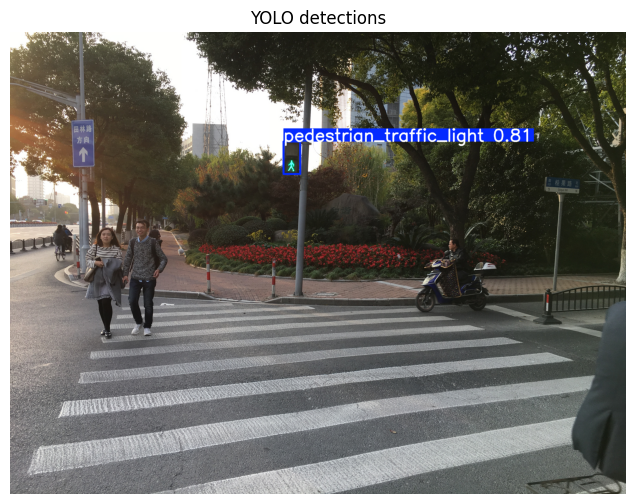

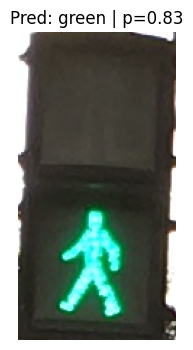

Detection meta: {'class_id': 0, 'class_name': 'pedestrian_traffic_light', 'confidence': 0.8110204935073853, 'bbox_xyxy': [1790, 716, 1899, 929], 'area': 23332, 'image_size': [4032, 3024]}
Class probabilities: {'green': 0.8346917629241943, 'red': 0.03702695667743683, 'yellow': 0.12828122079372406}
-> Walk


In [39]:
# ------------------ PIPELINE ------------------
# Set the path of the image to process:
IMAGE_PATH = "../data/PTL_Dataset_4032x3024_Part1/heon_IMG_0634.JPG" 
# ../data/PTL_Dataset_4032x3024_Part1/heon_IMG_0643.JPG 
# -> No pedestrian light detected with current thresholds.
# ../data/PTL_Dataset_4032x3024_Part1/heon_IMG_0634.JPG
# -> green light detected at 83%


# Detect + crop
crop, meta, annotated_bgr = crop_largest_detection(IMAGE_PATH, yolo_model=yolo, conf=0.35, iou=0.5, classes=YOLO_CLASSES)

# Visualize YOLO annotated full image
%matplotlib inline
plt.figure(figsize=(8,6))
plt.imshow(annotated_bgr[..., ::-1])  # BGR -> RGB
plt.axis('off')
plt.title("YOLO detections")
plt.show()

if crop is None:
    print("No pedestrian light detected with current thresholds.")
else:
    # Classify crop with SWIN
    x = swin_tfm(crop).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = swin(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    pred_class = swin_classes[pred_idx]

    # Show crop + prediction
    plt.figure(figsize=(4,4))
    plt.imshow(crop)
    plt.axis('off')
    plt.title(f"Pred: {pred_class} | p={probs[pred_idx]:.2f}")
    plt.show()

    print("Detection meta:", meta)
    print("Class probabilities:", {swin_classes[i]: float(probs[i]) for i in range(len(swin_classes))})

    conf = 0.8  # confidence threshold to decide Walk/Don't Walk
    # Tell the user Walk if green light with high confidence, "Don't Walk" if yellow or red light, "off" otherwise
    if pred_class == "green" and probs[pred_idx] > conf:
        print("-> Walk")
    elif pred_class in ["red", "yellow"] and probs[pred_idx] > conf:
        print("-> Don't Walk")
    else:
        print("-> off, no light detected")

In [48]:
import time, cv2, signal, sys, numpy as np
from pathlib import Path
from ultralytics import YOLO
import timm, torch
from torchvision import transforms
from PIL import Image

# --- config you can tweak ---
VIDEO_SRC = '../data/videos/zurich_vid_0.mp4' # use mp4 that OpenCV can read easily
OUT_PATH = '../data/videos/zurich_vid_0_processed.mp4'
CONF_YOLO = 0.35
IOU_YOLO  = 0.50
YOLO_IMGSZ = 640            # lower for faster
DECISION_PERIOD = 0.1       # seconds between inferences (≈ 10 Hz)
DECISION_CONF = 0.40        # Walk/Don’t Walk threshold
SHOW = True                 # live preview window (local)
SAVE = True                 # write annotated mp4
# ---------------------------


In [1]:
# ================================
# YOLOv10 + SWIN realtime video loop
# ================================
import os, time, signal
from pathlib import Path
import numpy as np
import torch
import cv2
from ultralytics import YOLO
import timm
from torchvision import transforms
from PIL import Image

# -------- CONFIG (EDIT THESE) --------
# Video source: path or webcam index (0)
VIDEO_SRC = "../data/videos/zurich_vid_1.mp4"  # or 0 for webcam

# Your trained weights
YOLO_BEST = "./runs/detect/zebraassist_15images/weights/best.pt"  # change to your run
SWIN_BEST = "./runs_swin/swin_tl_rgb/best_swin.pth"               # change to your run

# Class name from your YOLO detector (set to None to allow any class)
TARGET_CLASS_NAME = "pedestrian_traffic_light"

# Thresholds & pacing
CONF_YOLO       = 0.4
IOU_YOLO        = 0.50
YOLO_IMGSZ      = 640           # reduce (e.g., 512/416) if you need more speed
DECISION_PERIOD = 0.50          # seconds between heavy inferences (≈2 Hz)
DECISION_CONF   = 0.65          # probability threshold for decision output
SHOW            = True          # live window (local). In notebooks, consider False.
SAVE            = True          # write annotated mp4
OUT_PATH        = "../data/videos/zurich_vid_1_processed.mp4"
# -------------------------------------

# ---------- Device ----------
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    ("mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
)
print("Device:", device)

# ---------- Load YOLO ----------
if not Path(YOLO_BEST).exists():
    raise FileNotFoundError(f"YOLO weights not found at: {YOLO_BEST}")
yolo = YOLO(YOLO_BEST)

# Get numeric class id if requested
target_cls_id = None
if TARGET_CLASS_NAME and isinstance(yolo.names, dict):
    for k, v in yolo.names.items():
        if v == TARGET_CLASS_NAME:
            target_cls_id = int(k)
            break
print("YOLO target class id:", target_cls_id)

# ---------- Load SWIN ----------
if not Path(SWIN_BEST).exists():
    raise FileNotFoundError(f"SWIN checkpoint not found at: {SWIN_BEST}")
ckpt = torch.load(SWIN_BEST, map_location=device)
swin_classes = ckpt["classes"]
swin_name    = ckpt.get("model_name", "swin_tiny_patch4_window7_224")
img_size     = int(ckpt.get("img_size", 224))
swin         = timm.create_model(swin_name, pretrained=False, num_classes=len(swin_classes))
swin.load_state_dict(ckpt["model"])
swin.to(device).eval()

swin_tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def swin_predict_rgb(rgb_np: np.ndarray):
    """rgb_np: HxWx3 uint8 RGB. Returns (pred_class, pred_prob)."""
    with torch.no_grad():
        x = swin_tfm(Image.fromarray(rgb_np)).unsqueeze(0).to(device)
        probs = torch.softmax(swin(x), dim=1).cpu().numpy()[0]
    idx = int(np.argmax(probs))
    return swin_classes[idx], float(probs[idx])

def crop_largest_bgr(frame_bgr: np.ndarray, yolo_results, class_filter=None, conf_thr=0.0):
    """Pick largest-area detection. Return (crop_bgr, (x1,y1,x2,y2), det_conf, det_clsid) or (None, None, None, None)."""
    r = yolo_results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return None, None, None, None
    H, W = frame_bgr.shape[:2]
    boxes = r.boxes
    xyxy  = boxes.xyxy.cpu().numpy()            # (N,4)
    confs = boxes.conf.cpu().numpy()            # (N,)
    clsid = boxes.cls.cpu().numpy().astype(int) # (N,)

    keep = confs >= conf_thr
    if class_filter is not None:
        keep &= (clsid == class_filter)
    if not np.any(keep):
        return None, None, None, None

    xyxy  = xyxy[keep]
    confs = confs[keep]
    clsid = clsid[keep]

    # clamp + areas
    x1 = np.clip(xyxy[:,0], 0, W-1); y1 = np.clip(xyxy[:,1], 0, H-1)
    x2 = np.clip(xyxy[:,2], 0, W-1); y2 = np.clip(xyxy[:,3], 0, H-1)
    areas = np.maximum(0, x2-x1) * np.maximum(0, y2-y1)
    if areas.size == 0 or areas.max() <= 0:
        return None, None, None, None

    j = int(np.argmax(areas))
    x1,y1,x2,y2 = int(x1[j]), int(y1[j]), int(x2[j]), int(y2[j])
    return frame_bgr[y1:y2, x1:x2].copy(), (x1,y1,x2,y2), float(confs[j]), int(clsid[j])

# ---------- Open video ----------
cap = cv2.VideoCapture(VIDEO_SRC)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video source: {VIDEO_SRC}")

src_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
delay   = max(1, int(1000 / src_fps))
w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Source: {VIDEO_SRC} | FPS: {src_fps:.1f} | Size: {w}x{h}")

writer = None
if SAVE:
    Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(OUT_PATH, fourcc, src_fps, (w, h))

win = "YOLO+SWIN (realtime look)"
if SHOW:
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)

# graceful Ctrl+C
stop = {"flag": False}
def _sigint(_a,_b): stop["flag"] = True
signal.signal(signal.SIGINT, _sigint)

# ---------- Realtime loop with periodic inference ----------
last_decision = "off"
last_color    = (128,128,128)
last_box      = None
last_prob     = 0.0
last_infer_t  = 0.0
t0            = time.time()
frame_idx     = 0

try:
    while True:
        if stop["flag"]:
            break

        ok, frame_bgr = cap.read()
        if not ok:
            break
        frame_idx += 1
        now = time.time()

        # Run heavy inference only every DECISION_PERIOD seconds
        if (now - last_infer_t) >= DECISION_PERIOD:
            yres = yolo(frame_bgr, conf=CONF_YOLO, iou=IOU_YOLO, imgsz=YOLO_IMGSZ, verbose=False)
            crop_bgr, bbox, dconf, did = crop_largest_bgr(frame_bgr, yres, class_filter=target_cls_id, conf_thr=CONF_YOLO)

            if crop_bgr is not None and crop_bgr.size > 0:
                crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
                pred_class, pred_prob = swin_predict_rgb(crop_rgb)

                if pred_class == "green" and pred_prob >= DECISION_CONF:
                    last_decision, last_color = "Walk", (0,200,0)
                elif pred_class in ("red","yellow") and pred_prob >= DECISION_CONF:
                    last_decision, last_color = "Don't Walk", (0,0,220)
                else:
                    last_decision, last_color = "off", (128,128,128)

                last_box  = bbox
                last_prob = pred_prob
            else:
                last_decision, last_color = "off", (128,128,128)
                last_box  = None
                last_prob = 0.0

            last_infer_t = now  # update

        # ---- overlay (uses last decision) ----
        if last_box is not None:
            x1,y1,x2,y2 = last_box
            cv2.rectangle(frame_bgr, (x1,y1), (x2,y2), last_color, 2)

        fps = frame_idx / max(1e-6, (now - t0))
        label = f"{last_decision} ({last_prob:.2f})  FPS:{fps:.1f}"
        cv2.rectangle(frame_bgr, (10,10), (10+380, 50), (0,0,0), -1)
        cv2.putText(frame_bgr, label, (20,40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, last_color, 2, cv2.LINE_AA)

        if writer is not None:
            writer.write(frame_bgr)

        if SHOW:
            cv2.imshow(win, frame_bgr)
            # allow closing by clicking the [X]
            if cv2.getWindowProperty(win, cv2.WND_PROP_VISIBLE) < 1:
                break
            key = cv2.waitKey(delay) & 0xFF
            if key in (27, ord('q')):  # Esc or 'q'
                break

finally:
    # ---------- guaranteed cleanup ----------
    try: cap.release()
    except: pass
    try:
        if writer is not None:
            writer.release()
    except: pass
    try:
        if SHOW:
            cv2.destroyWindow(win)
            for _ in range(3):  # flush GUI events (macOS quirk)
                cv2.waitKey(1)
        cv2.destroyAllWindows()
        for _ in range(3):
            cv2.waitKey(1)
    except: pass

print("✅ Done. Saved:", OUT_PATH if SAVE else "(not saved)")


/Users/mothiam/Documents/Mouha Perso/HSLU/Semester3/Computer_vision/Project/zebrAssist/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/mothiam/Documents/Mouha Perso/HSLU/Semester3/Computer_vision/Project/zebrAssist/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
YOLO target class id: 0
Source: ../data/videos/zurich_vid_1.mp4 | FPS: 30.0 | Size: 480x848
✅ Done. Saved: ../data/videos/zurich_vid_1_processed.mp4


In [6]:
# ================================
# YOLOv10 + SWIN realtime video loop + ZEBRA gate (yellow stripes)
# Exit LIGHT mode only if YOLO light is lost for N seconds
# ================================
import os, time, signal
from pathlib import Path
import numpy as np
import torch
import cv2
from ultralytics import YOLO
import timm
from torchvision import transforms
from PIL import Image

# -------- CONFIG (EDIT THESE) --------
VIDEO_SRC = "../data/videos/zurich_vid_1.mp4"  # or 0 for webcam

YOLO_BEST = "./runs/detect/zebraassist_15images/weights/best.pt"
SWIN_BEST = "./runs_swin/swin_tl_rgb/best_swin.pth"

TARGET_CLASS_NAME = "pedestrian_traffic_light"

# Thresholds & pacing
CONF_YOLO       = 0.4
IOU_YOLO        = 0.50
YOLO_IMGSZ      = 640
DECISION_PERIOD = 1         # seconds between YOLO+SWIN runs
DECISION_CONF   = 0.65
SHOW            = True
SAVE            = True
OUT_PATH        = "../data/videos/zurich_vid_1_processed.mp4"

# --- ZEBRA GATE (yellow stripes) ---
ZEBRA_ROI_REL       = (0.45, 0.95, 0.15, 0.85)  # (ymin,ymax,xmin,xmax) as fractions of H,W (lower-middle)
ZEBRA_CHECK_PERIOD  = 0.25                      # run zebra detector every 0.25s (fast)
ZEBRA_OK_FOR_SEC    = 1.5                       # if found, keep gate open for this long
ZEBRA_MIN_WIDTH_FR  = 0.25                      # zebra bbox must be at least this fraction of image width
ZEBRA_ANGLE_TOL_DEG = 25                        # stripes ~ horizontal within ±deg

# --- state machine knobs ---
# (The older LIGHT_LOST_TIMEOUT rule is removed.)
YOLO_LOST_TIMEOUT = 5.0          # <-- Exit LIGHT mode only if YOLO light disappears for this long
LIGHT_CONF = DECISION_CONF

# -------------------------------------

# ---------- Device ----------
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    ("mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
)
print("Device:", device)

# ---------- Load YOLO ----------
if not Path(YOLO_BEST).exists():
    raise FileNotFoundError(f"YOLO weights not found at: {YOLO_BEST}")
yolo = YOLO(YOLO_BEST)

target_cls_id = None
if TARGET_CLASS_NAME and isinstance(yolo.names, dict):
    for k, v in yolo.names.items():
        if v == TARGET_CLASS_NAME:
            target_cls_id = int(k)
            break
print("YOLO target class id:", target_cls_id)

# ---------- Load SWIN ----------
if not Path(SWIN_BEST).exists():
    raise FileNotFoundError(f"SWIN checkpoint not found at: {SWIN_BEST}")
ckpt = torch.load(SWIN_BEST, map_location=device)
swin_classes = ckpt["classes"]
swin_name    = ckpt.get("model_name", "swin_tiny_patch4_window7_224")
img_size     = int(ckpt.get("img_size", 224))
swin         = timm.create_model(swin_name, pretrained=False, num_classes=len(swin_classes))
swin.load_state_dict(ckpt["model"])
swin.to(device).eval()

swin_tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def swin_predict_rgb(rgb_np: np.ndarray):
    """rgb_np: HxWx3 uint8 RGB. Returns (pred_class, pred_prob)."""
    with torch.no_grad():
        x = swin_tfm(Image.fromarray(rgb_np)).unsqueeze(0).to(device)
        probs = torch.softmax(swin(x), dim=1).cpu().numpy()[0]
    idx = int(np.argmax(probs))
    return swin_classes[idx], float(probs[idx])

def crop_largest_bgr(frame_bgr: np.ndarray, yolo_results, class_filter=None, conf_thr=0.0):
    """Pick largest-area detection. Return (crop_bgr, (x1,y1,x2,y2), det_conf, det_clsid) or (None, None, None, None)."""
    r = yolo_results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return None, None, None, None
    H, W = frame_bgr.shape[:2]
    boxes = r.boxes
    xyxy  = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    clsid = boxes.cls.cpu().numpy().astype(int)

    keep = confs >= conf_thr
    if class_filter is not None:
        keep &= (clsid == class_filter)
    if not np.any(keep):
        return None, None, None, None

    xyxy  = xyxy[keep]
    confs = confs[keep]
    clsid = clsid[keep]

    x1 = np.clip(xyxy[:,0], 0, W-1); y1 = np.clip(xyxy[:,1], 0, H-1)
    x2 = np.clip(xyxy[:,2], 0, W-1); y2 = np.clip(xyxy[:,3], 0, H-1)
    areas = np.maximum(0, x2-x1) * np.maximum(0, y2-y1)
    if areas.size == 0 or areas.max() <= 0:
        return None, None, None, None

    j = int(np.argmax(areas))
    x1,y1,x2,y2 = int(x1[j]), int(y1[j]), int(x2[j]), int(y2[j])
    return frame_bgr[y1:y2, x1:x2].copy(), (x1,y1,x2,y2), float(confs[j]), int(clsid[j])

# ---------- Zebra crossing detector (YELLOW stripes) ----------
def detect_zebra_crossing(
    frame_bgr: np.ndarray,
    roi_rel=(0.45, 0.95, 0.15, 0.85),  # (ymin, ymax, xmin, xmax) in [0,1]
    min_width_frac=0.25,
    angle_accept_deg=25,
) -> tuple[bool, float | None, np.ndarray | None]:
    """
    Returns (found, angle_deg, zebra_poly). Angle is 0=horizontal (±).
    """
    H, W = frame_bgr.shape[:2]
    y0 = int(roi_rel[0]*H); y1 = int(roi_rel[1]*H)
    x0 = int(roi_rel[2]*W); x1 = int(roi_rel[3]*W)
    roi = frame_bgr[y0:y1, x0:x1]

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    # --- YELLOW mask (tune if needed) ---
    # Hue ~15-35, sat >=80, val >=150 (good default for yellow road paint)
    yellow_mask = cv2.inRange(hsv, (15, 80, 150), (35, 255, 255))

    # Clean up
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(yellow_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Edges/lines
    edges = cv2.Canny(mask, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80,
                            minLineLength=max(20, roi.shape[1]//8), maxLineGap=10)
    if lines is None:
        return False, None, None
    lines = lines[:,0,:]  # (N,4)

    angs = []
    for x1_,y1_,x2_,y2_ in lines:
        dx = x2_-x1_; dy = y2_-y1_
        L = np.hypot(dx, dy)
        if L < 10:
            continue
        ang = np.degrees(np.arctan2(dy, dx))  # 0=horizontal
        if ang > 90: ang -= 180
        if ang < -90: ang += 180
        angs.append(ang)
    if not angs:
        return False, None, None

    angs = np.array(angs)
    sel = np.abs(angs) <= angle_accept_deg
    if sel.sum() < 6:  # need enough near-horizontal segments
        return False, None, None

    dom_angle = float(np.median(angs[sel]))

    # Biggest yellow region bbox as zebra proxy
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return False, None, None
    cnt = max(cnts, key=cv2.contourArea)
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect).astype(int)
    box[:,0] += x0; box[:,1] += y0

    # width constraint (must be "in front")
    bbox_w = max(np.linalg.norm(box[0]-box[1]), np.linalg.norm(box[1]-box[2]))
    if bbox_w < min_width_frac * W:
        return False, None, None

    return True, dom_angle, box

# ---------- Open video ----------
cap = cv2.VideoCapture(VIDEO_SRC)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video source: {VIDEO_SRC}")

src_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
delay   = max(1, int(1000 / src_fps))
w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Source: {VIDEO_SRC} | FPS: {src_fps:.1f} | Size: {w}x{h}")

writer = None
if SAVE:
    Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(OUT_PATH, fourcc, src_fps, (w, h))

win = "YOLO+SWIN (realtime look)"
if SHOW:
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)

# graceful Ctrl+C
stop = {"flag": False}
def _sigint(_a,_b): stop["flag"] = True
signal.signal(signal.SIGINT, _sigint)

# ---------- Realtime loop ----------
STATE_SEARCH_ZEBRA = 0
STATE_LIGHT_MODE   = 1
state = STATE_SEARCH_ZEBRA

last_decision = "off"
last_color    = (128,128,128)
last_box      = None
last_prob     = 0.0

# Zebra entry bookkeeping
zebra_last_check = 0.0

# Light cadence & YOLO recency (for exit rule)
last_infer_t    = 0.0            # last YOLO+SWIN inference time
yolo_seen       = False          # have we seen the light (YOLO) since entering LIGHT mode?
last_yolo_time  = 0.0            # last time YOLO detected the light

t0        = time.time()
frame_idx = 0

try:
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        frame_idx += 1
        now = time.time()

        if state == STATE_SEARCH_ZEBRA:
            # Gate: only used to enter LIGHT_MODE
            if (now - zebra_last_check) >= ZEBRA_CHECK_PERIOD:
                zebra_ok, zebra_angle, zebra_poly = detect_zebra_crossing(
                    frame_bgr,
                    roi_rel=ZEBRA_ROI_REL,
                    min_width_frac=ZEBRA_MIN_WIDTH_FR,
                    angle_accept_deg=ZEBRA_ANGLE_TOL_DEG,
                )
                zebra_last_check = now
                if zebra_ok:
                    state = STATE_LIGHT_MODE
                    # reset light status on entry
                    last_box = None
                    last_decision, last_color, last_prob = "off", (128,128,128), 0.0
                    yolo_seen = False
                    last_yolo_time = 0.0

            # Overlay for SEARCH_ZEBRA
            cv2.putText(frame_bgr, "ZEBRA: searching...", (20, h-20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (80,80,80), 2, cv2.LINE_AA)

        elif state == STATE_LIGHT_MODE:
            # Run light inference at cadence
            if (now - last_infer_t) >= DECISION_PERIOD:
                yres = yolo(frame_bgr, conf=CONF_YOLO, iou=IOU_YOLO, imgsz=YOLO_IMGSZ, verbose=False)
                crop_bgr, bbox, dconf, did = crop_largest_bgr(
                    frame_bgr, yres, class_filter=target_cls_id, conf_thr=CONF_YOLO
                )

                # Record YOLO presence (independent of SWIN color)
                if crop_bgr is not None and crop_bgr.size > 0:
                    yolo_seen = True
                    last_yolo_time = now

                    # Classify the detected light
                    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
                    pred_class, pred_prob = swin_predict_rgb(crop_rgb)

                    if pred_class == "green" and pred_prob >= DECISION_CONF:
                        last_decision, last_color = "Walk", (0,200,0)
                        last_box, last_prob = bbox, pred_prob
                    elif pred_class in ("red","yellow") and pred_prob >= DECISION_CONF:
                        last_decision, last_color = "Don't Walk", (0,0,220)
                        last_box, last_prob = bbox, pred_prob
                    # else: keep previous decision
                else:
                    # No YOLO detection this cycle; keep previous decision
                    pass

                last_infer_t = now

            # Exit condition: YOLO light missing for YOLO_LOST_TIMEOUT (but only after we've seen it at least once)
            yolo_recent = (now - last_yolo_time) <= YOLO_LOST_TIMEOUT if yolo_seen else True
            if not yolo_recent:
                state = STATE_SEARCH_ZEBRA
                last_box = None
                last_decision, last_color, last_prob = "off", (128,128,128), 0.0
                yolo_seen = False
                last_yolo_time = 0.0

            # Overlay for LIGHT_MODE
            cv2.putText(frame_bgr, "LIGHT MODE", (20, h-20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,200,200), 2, cv2.LINE_AA)

        # ---- Common overlays (box + decision + FPS) ----
        if last_box is not None:
            x1,y1,x2,y2 = last_box
            cv2.rectangle(frame_bgr, (x1,y1), (x2,y2), last_color, 2)

        fps = frame_idx / max(1e-6, (now - t0))
        label = f"{last_decision} ({last_prob:.2f})  FPS:{fps:.1f}"
        cv2.rectangle(frame_bgr, (10,10), (10+380, 50), (0,0,0), -1)
        cv2.putText(frame_bgr, label, (20,40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, last_color, 2, cv2.LINE_AA)

        if writer is not None:
            writer.write(frame_bgr)

        if SHOW:
            cv2.imshow(win, frame_bgr)
            if cv2.getWindowProperty(win, cv2.WND_PROP_VISIBLE) < 1:
                break
            key = cv2.waitKey(max(1, int(1000 / src_fps))) & 0xFF
            if key in (27, ord('q')):
                break

finally:
    try: cap.release()
    except: pass
    try:
        if writer is not None: writer.release()
    except: pass
    try:
        if SHOW:
            cv2.destroyWindow(win)
            for _ in range(3): cv2.waitKey(1)
        cv2.destroyAllWindows()
        for _ in range(3): cv2.waitKey(1)
    except: pass

print("✅ Done. Saved:", OUT_PATH if SAVE else "(not saved)")


Device: mps
YOLO target class id: 0
Source: ../data/videos/zurich_vid_1.mp4 | FPS: 30.0 | Size: 480x848
✅ Done. Saved: ../data/videos/zurich_vid_1_processed.mp4
